# Term Deposit Subscription Prediction (Bank Marketing)
## Advanced Classification & Explainable AI Project

---

## 1. Problem Statement and Objective

### Business Problem:
A Portuguese bank conducts telemarketing campaigns to promote term deposit subscriptions. The bank needs to **predict whether a customer will subscribe to a term deposit** based on their demographic and behavioral characteristics.

### Objectives:
1. Build a **classification model** to predict deposit subscription likelihood
2. Identify **key features** influencing customer decisions
3. Provide **interpretable predictions** using SHAP/LIME for business stakeholders
4. Evaluate model performance using multiple metrics (Accuracy, F1-Score, ROC-AUC)

### Success Criteria:
- Achieve F1-Score > 0.70 on test set
- Identify top 5 most influential features
- Provide explainable predictions for business decision-making

## 2. Dataset Description and Loading

In [2]:
# Install and import necessary libraries with error handling
import subprocess
import sys
import warnings
warnings.filterwarnings('ignore')

# List of required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'shap': 'shap'
}

print("📦 Checking and installing required packages...\n")

for import_name, pip_name in required_packages.items():
    try:
        __import__(import_name)
        print(f" {import_name:15} - Already installed")
    except ImportError:
        print(f" {import_name:15} - Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        print(f" {import_name:15} - Installed successfully")

print("\n" + "="*36)

# Now import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score, roc_auc_score

# Try to import SHAP, handle if unavailable
try:
    import shap
    SHAP_AVAILABLE = True
    print(" SHAP library imported successfully!")
except ImportError:
    SHAP_AVAILABLE = False
    print("  SHAP library not available (optional)")
    print("   Install with: pip install shap")

print("="*36)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("\n All core libraries imported successfully!\n")

📦 Checking and installing required packages...

 pandas          - Already installed
 numpy           - Already installed
 sklearn         - Already installed
 matplotlib      - Already installed
 seaborn         - Already installed
 shap            - Already installed

 SHAP library imported successfully!

 All core libraries imported successfully!



In [3]:
# Load the dataset
df = pd.read_csv('bank.csv')

print(" Dataset Shape:", df.shape)
print("\n First Few Rows:")
print(df.head())
print("\n Dataset Info:")
print(df.info())
print("\n Statistical Summary:")
print(df.describe())

 Dataset Shape: (11162, 17)

 First Few Rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>

In [4]:
# Column names and types
print(" Column Names and Data Types:")
print(df.dtypes)
print("\n Target Variable Distribution:")
print(df['deposit'].value_counts())
print("\nTarget Proportion (%):\n", df['deposit'].value_counts(normalize=True) * 100)

 Column Names and Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

 Target Variable Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Target Proportion (%):
 deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


### Dataset Features Explanation:

**Customer Demographics:**
- `age`: Customer age
- `job`: Type of job (categorical)
- `marital`: Marital status (categorical)
- `education`: Educational level (categorical)
- `default`: Has credit in default? (yes/no)

**Customer Financial Profile:**
- `balance`: Annual balance in EUR
- `housing`: Has housing loan? (yes/no)
- `loan`: Has personal loan? (yes/no)

**Campaign Related:**
- `contact`: Type of contact (cellular/telephone)
- `day`: Last contact day of the month
- `month`: Last contact month (categorical)
- `duration`: Last contact duration in seconds
- `campaign`: Number of contacts during this campaign
- `pdays`: Days since last contact from previous campaign
- `previous`: Number of contacts before this campaign
- `poutcome`: Outcome of previous campaign (categorical)

**Target Variable:**
- `deposit`: Did customer subscribe to term deposit? (yes/no)

## 3. Data Cleaning and Preprocessing

In [5]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" No missing values detected!")
else:
    print(missing[missing > 0])

Missing Values:
 No missing values detected!


In [6]:
# Create a copy for preprocessing
df_clean = df.copy()

# Identify categorical and numerical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f" Categorical Columns ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\n Numerical Columns ({len(numerical_cols)}):")
print(numerical_cols)

 Categorical Columns (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

 Numerical Columns (7):
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [7]:
# Separate target variable
y = df_clean['deposit'].map({'yes': 1, 'no': 0})
X = df_clean.drop('deposit', axis=1)

print(f" Target Variable (y) shape: {y.shape}")
print(f" Features (X) shape: {X.shape}")
print(f"\n Class Distribution:")
print(f"Class 0 (No deposit): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Class 1 (Deposit): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

 Target Variable (y) shape: (11162,)
 Features (X) shape: (11162, 16)

 Class Distribution:
Class 0 (No deposit): 5873 (52.6%)
Class 1 (Deposit): 5289 (47.4%)


## Encode all categorical features

In [8]:
# 🔧 FEATURE ENCODING - Encode all categorical variables

# Create a copy of X for encoding
X_encoded = X.copy()

# Binary encoding for yes/no columns
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X_encoded[col] = X_encoded[col].map({'yes': 1, 'no': 0})

print(" Binary columns encoded")

# One-hot encoding for multi-class categorical variables
categorical_to_encode = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
X_encoded = pd.get_dummies(X_encoded, columns=categorical_to_encode, drop_first=True)

print(f" Categorical columns one-hot encoded")
print(f"\n Final Feature Set Shape: {X_encoded.shape}")
print(f" Feature Names (first 20):\n {X_encoded.columns.tolist()[:20]}")

 Binary columns encoded
 Categorical columns one-hot encoded

 Final Feature Set Shape: (11162, 42)
 Feature Names (first 20):
 ['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed']


In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Train-Test Split (80-20):")
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\n Class distribution in training set:")
print(y_train.value_counts())
print(f"\n Class distribution in testing set:")
print(y_test.value_counts())

 Train-Test Split (80-20):
Training set: (8929, 42)
Testing set: (2233, 42)

 Class distribution in training set:
deposit
0    4698
1    4231
Name: count, dtype: int64

 Class distribution in testing set:
deposit
0    1175
1    1058
Name: count, dtype: int64


In [10]:
# Feature scaling for models that benefit from it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(" Features scaled using StandardScaler")
print(f"\nTraining set - Mean: {X_train_scaled.mean().mean():.4f}, Std: {X_train_scaled.std().mean():.4f}")
print(f"Testing set - Mean: {X_test_scaled.mean().mean():.4f}, Std: {X_test_scaled.std().mean():.4f}")

 Features scaled using StandardScaler

Training set - Mean: 0.0000, Std: 1.0001
Testing set - Mean: 0.0062, Std: 1.0112


## 4. Exploratory Data Analysis (EDA)

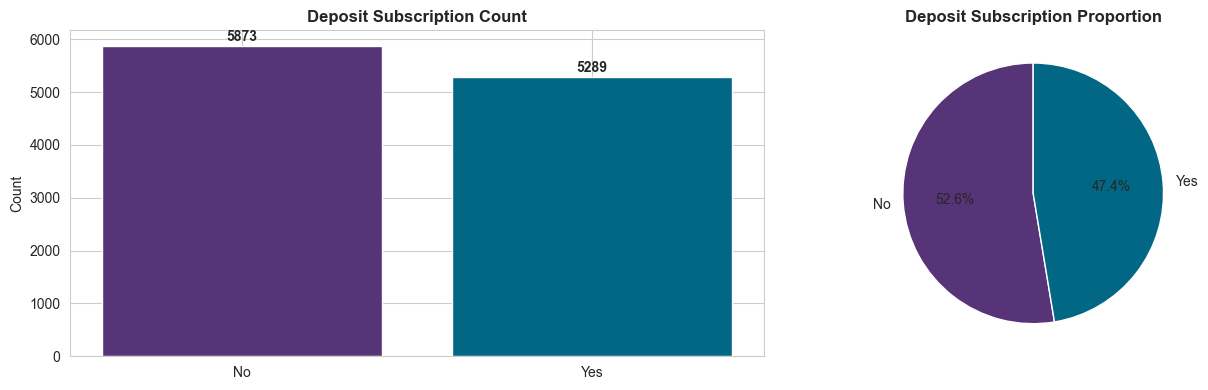

💡 Insight: The dataset is imbalanced with 47.4% positive class (Deposit = Yes)


In [23]:
# Distribution of Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Count plot
deposit_counts = df['deposit'].value_counts()
axes[0].bar(['No', 'Yes'], deposit_counts.values, color=['#563477', '#016784'])
axes[0].set_title('Deposit Subscription Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(deposit_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(deposit_counts.values, labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=['#563477', '#016784'], startangle=90)
axes[1].set_title('Deposit Subscription Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_deposit_subscription.png', bbox_inches='tight')
plt.show()

print(f"💡 Insight: The dataset is imbalanced with {(y==1).sum()/len(y)*100:.1f}% positive class (Deposit = Yes)")

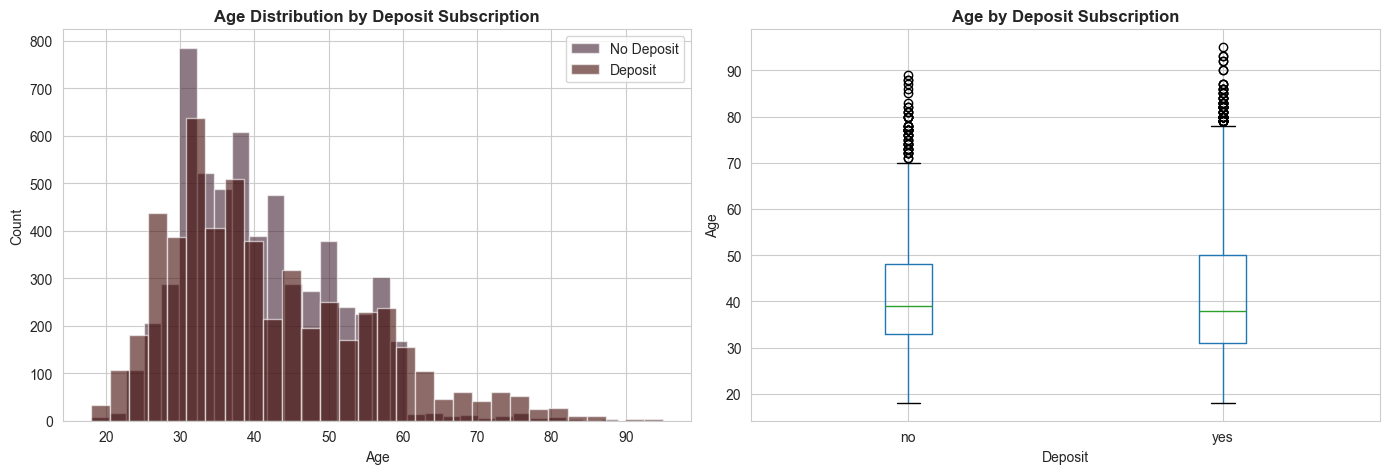

💡 Insight: Deposit subscribers tend to be older (Mean: 41.7) vs non-subscribers (Mean: 40.8)


In [27]:
# Age distribution by deposit subscription
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[df['deposit']=='no']['age'], bins=30, alpha=0.6, label='No Deposit', color='#402030')
axes[0].hist(df[df['deposit']=='yes']['age'], bins=30, alpha=0.6, label='Deposit', color='#400905')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Deposit Subscription', fontweight='bold')
axes[0].legend()

# Box plot
df.boxplot(column='age', by='deposit', ax=axes[1])
axes[1].set_title('Age by Deposit Subscription', fontweight='bold')
axes[1].set_xlabel('Deposit')
axes[1].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plot2_age_distribution.png', bbox_inches='tight')
plt.show()

print(f"💡 Insight: Deposit subscribers tend to be older (Mean: {df[df['deposit']=='yes']['age'].mean():.1f}) vs non-subscribers (Mean: {df[df['deposit']=='no']['age'].mean():.1f})")

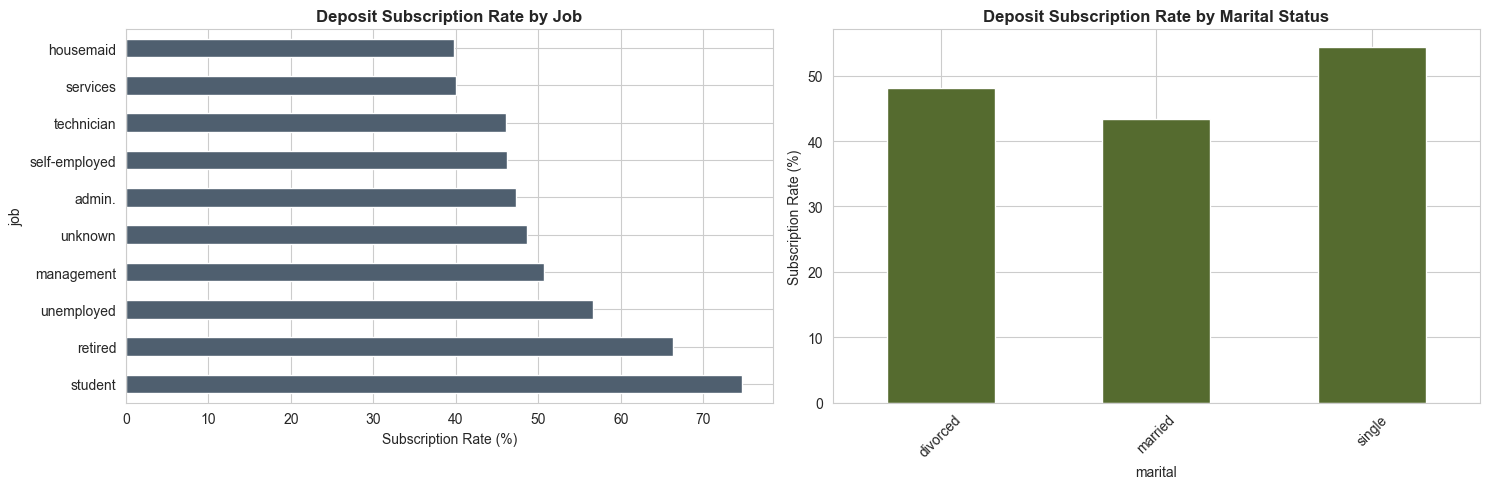

In [33]:
# Job and Marital Status distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Job distribution
job_deposit = pd.crosstab(df['job'], df['deposit'], normalize='index') * 100
job_deposit['yes'].sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[0], color='#4F5F6F')
axes[0].set_title('Deposit Subscription Rate by Job', fontweight='bold')
axes[0].set_xlabel('Subscription Rate (%)')

# Marital status distribution
marital_deposit = pd.crosstab(df['marital'], df['deposit'], normalize='index') * 100
marital_deposit['yes'].plot(kind='bar', ax=axes[1], color='#556B2F')
axes[1].set_title('Deposit Subscription Rate by Marital Status', fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('plot3_job_marital_dist.png', bbox_inches='tight')
plt.show()

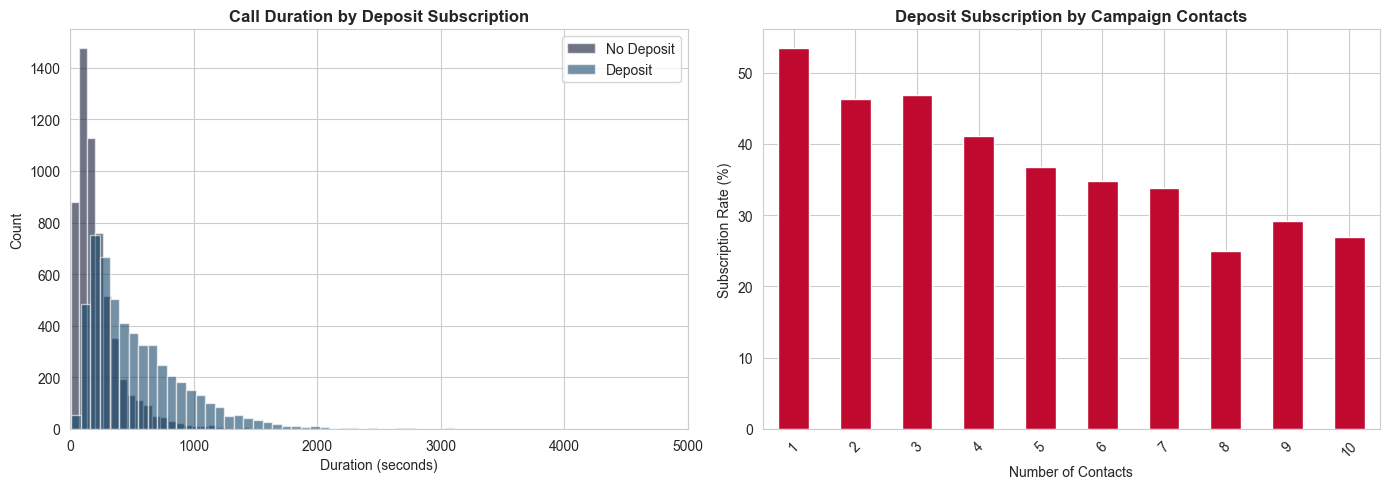

💡 Insight: Longer call duration strongly correlates with deposit subscription (median duration for subscribers: 426s vs non-subscribers: 163s)


In [36]:
# Contact duration and campaign frequency impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration analysis
axes[0].hist(df[df['deposit']=='no']['duration'], bins=50, alpha=0.6, label='No Deposit', color='#111632')
axes[0].hist(df[df['deposit']=='yes']['duration'], bins=50, alpha=0.6, label='Deposit', color='#16476A')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Call Duration by Deposit Subscription', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 5000)  # Limit x-axis for better visualization

# Campaign frequency
campaign_deposit = pd.crosstab(df['campaign'], df['deposit'], normalize='index') * 100
campaign_deposit['yes'].head(10).plot(kind='bar', ax=axes[1], color='#BF092F')
axes[1].set_title('Deposit Subscription by Campaign Contacts', fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_xlabel('Number of Contacts')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('plot4_duration_freqimpact.png', bbox_inches='tight')
plt.show()

print(f"💡 Insight: Longer call duration strongly correlates with deposit subscription (median duration for subscribers: {df[df['deposit']=='yes']['duration'].median():.0f}s vs non-subscribers: {df[df['deposit']=='no']['duration'].median():.0f}s)")

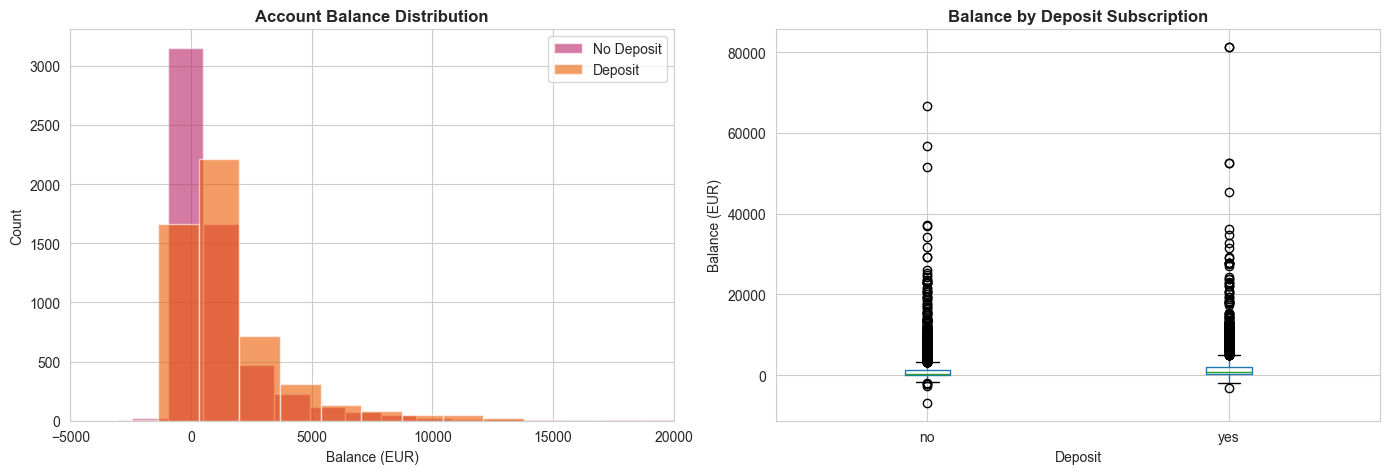

💡 Insight: Deposit subscribers have higher average balance (Mean: 1804 EUR) vs non-subscribers (Mean: 1280 EUR)


In [39]:
# Balance analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[df['deposit']=='no']['balance'], bins=50, alpha=0.6, label='No Deposit', color='#BA2264')
axes[0].hist(df[df['deposit']=='yes']['balance'], bins=50, alpha=0.6, label='Deposit', color='#EB5B00')
axes[0].set_xlabel('Balance (EUR)')
axes[0].set_ylabel('Count')
axes[0].set_title('Account Balance Distribution', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(-5000, 20000)  # Limit for visualization

# Box plot
df.boxplot(column='balance', by='deposit', ax=axes[1])
axes[1].set_title('Balance by Deposit Subscription', fontweight='bold')
axes[1].set_xlabel('Deposit')
axes[1].set_ylabel('Balance (EUR)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plot5_balance.png', bbox_inches='tight')
plt.show()

print(f"💡 Insight: Deposit subscribers have higher average balance (Mean: {df[df['deposit']=='yes']['balance'].mean():.0f} EUR) vs non-subscribers (Mean: {df[df['deposit']=='no']['balance'].mean():.0f} EUR)")

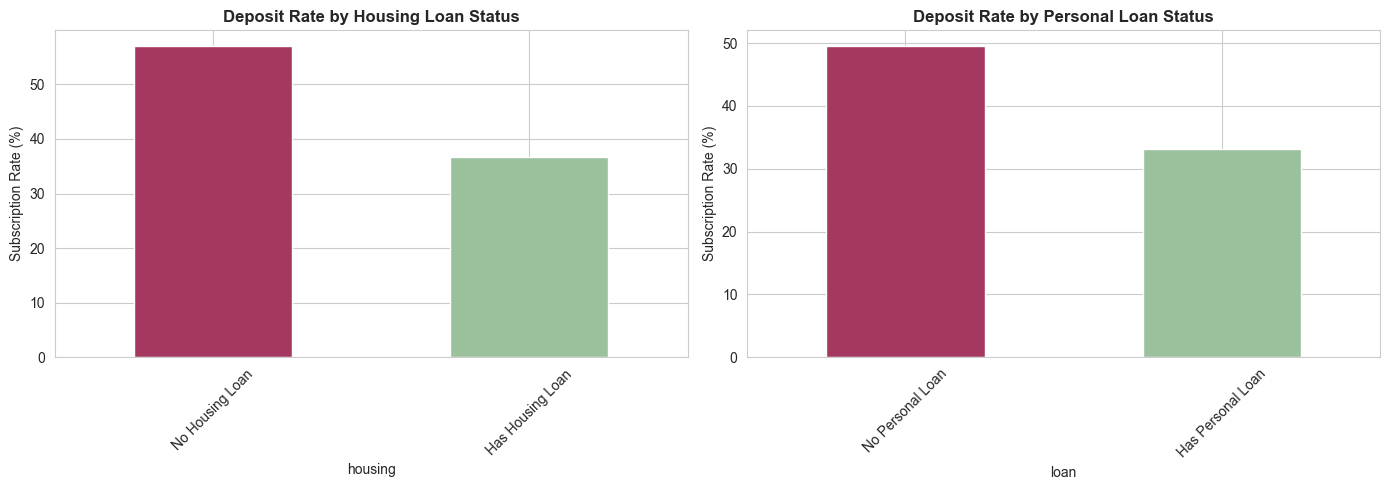

In [40]:
# Loan and Housing status impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Housing loan
housing_deposit = pd.crosstab(df['housing'], df['deposit'], normalize='index') * 100
housing_deposit['yes'].plot(kind='bar', ax=axes[0], color=['#A53860', '#9BC09C'])
axes[0].set_title('Deposit Rate by Housing Loan Status', fontweight='bold')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].set_xticklabels(['No Housing Loan', 'Has Housing Loan'], rotation=45)

# Personal loan
loan_deposit = pd.crosstab(df['loan'], df['deposit'], normalize='index') * 100
loan_deposit['yes'].plot(kind='bar', ax=axes[1], color=['#A53860', '#9BC09C'])
axes[1].set_title('Deposit Rate by Personal Loan Status', fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_xticklabels(['No Personal Loan', 'Has Personal Loan'], rotation=45)

plt.tight_layout()
plt.savefig('plot6_loanimpacts.png', bbox_inches='tight')
plt.show()

## 5. Model Building and Evaluation

In [41]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

# Store results
model_results = {}
trained_models = {}

print(" Training Classification Models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Use scaled data for Logistic Regression, original for tree-based models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    model_results[name] = {
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    trained_models[name] = model
    
    print(f" {name} - F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")

 Training Classification Models...

Training Logistic Regression...
 Logistic Regression - F1-Score: 0.8131, ROC-AUC: 0.9072

Training Random Forest...
 Random Forest - F1-Score: 0.8464, ROC-AUC: 0.9176

Training Gradient Boosting...
 Gradient Boosting - F1-Score: 0.8575, ROC-AUC: 0.9308



In [42]:
# Compare models
comparison_df = pd.DataFrame(model_results).T[['F1-Score', 'ROC-AUC']]
print("Model Comparison:")
print(comparison_df.round(4))

# Best model
best_model_name = comparison_df['F1-Score'].idxmax()
print(f"\nBest Model: {best_model_name}")

Model Comparison:
                     F1-Score   ROC-AUC
Logistic Regression  0.813071  0.907194
Random Forest        0.846435  0.917615
Gradient Boosting    0.857537  0.930792

Best Model: Gradient Boosting


### Confusion Matrix Analysis

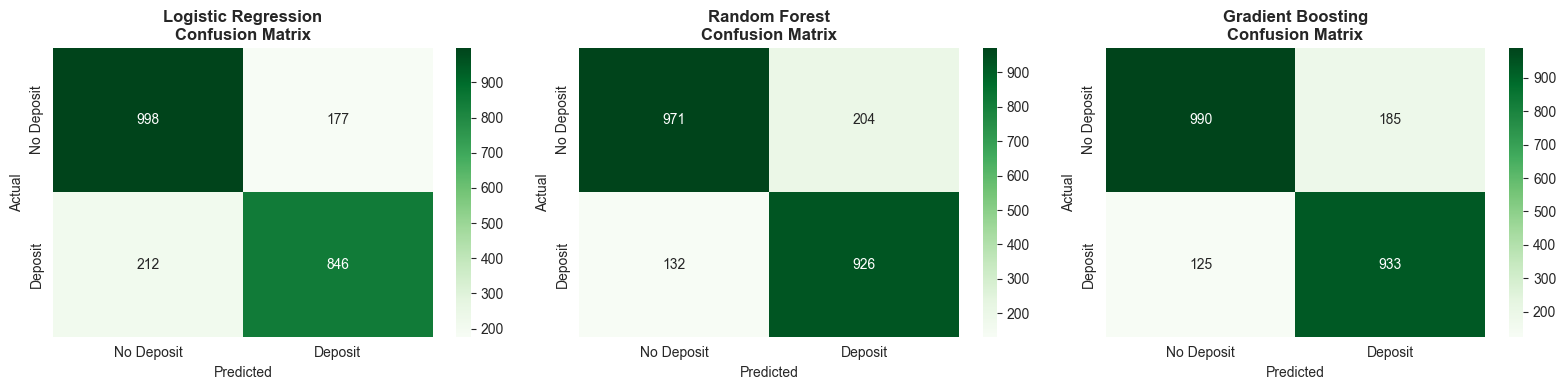

In [43]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, results) in enumerate(model_results.items()):
    cm = confusion_matrix(y_test, results['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=['No Deposit', 'Deposit'],
                yticklabels=['No Deposit', 'Deposit'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plot7_confusionmatrix.png', bbox_inches='tight')
plt.show()

### Classification Report (Precision, Recall, F1-Score)

In [44]:
# Detailed classification reports
for name, results in model_results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report - {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, results['y_pred'],
                              target_names=['No Deposit', 'Deposit']))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

  No Deposit       0.82      0.85      0.84      1175
     Deposit       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233


Classification Report - Random Forest
              precision    recall  f1-score   support

  No Deposit       0.88      0.83      0.85      1175
     Deposit       0.82      0.88      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233


Classification Report - Gradient Boosting
              precision    recall  f1-score   support

  No Deposit       0.89      0.84      0.86      1175
     Deposit       0.83      0.88      0.86      1058

    accuracy                           0.86      2233
 

### ROC Curve Analysis

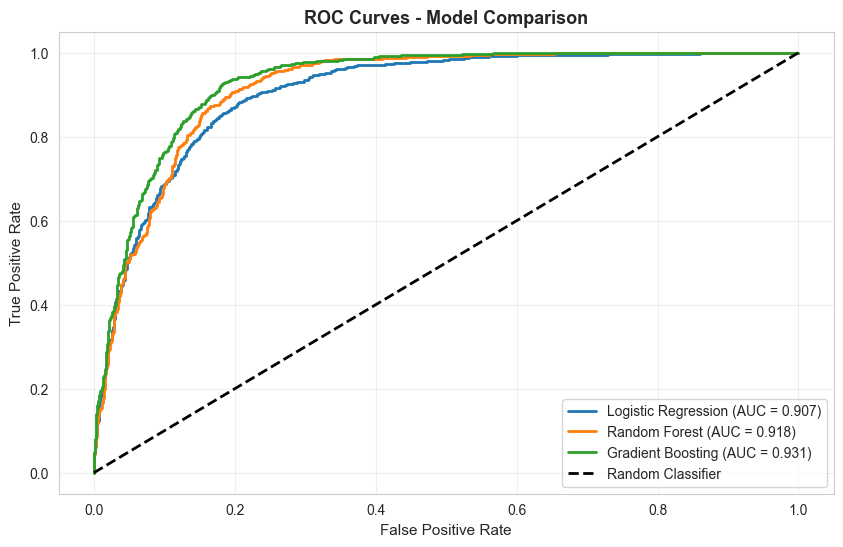

💡 Insight: ROC-AUC measures the model's ability to distinguish between classes. Higher is better (max=1.0).


In [45]:
# ROC curves for all models
plt.figure(figsize=(10, 6))

for name, results in model_results.items():
    fpr, tpr, thresholds = roc_curve(y_test, results['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves - Model Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('plot8_ROC.png', bbox_inches='tight')
plt.show()

print("💡 Insight: ROC-AUC measures the model's ability to distinguish between classes. Higher is better (max=1.0).")

## 6. Model Interpretability - SHAP Analysis

In [46]:
# Select best model for SHAP analysis
print(f"🔍 Using {best_model_name} for Explainability Analysis\n")

best_model = trained_models[best_model_name]

# Create SHAP explainer based on model type
if not SHAP_AVAILABLE:
    print("⚠️  SHAP library not available. Skipping SHAP analysis.")
    print("\nTo enable SHAP analysis, install it with:")
    print("   pip install shap")
    print("\nAlternatively, you can use LIME for model explanations.")
    SHAP_ANALYSIS_POSSIBLE = False
else:
    try:
        if best_model_name == 'Logistic Regression':
            explainer = shap.LinearExplainer(best_model, X_train_scaled)
            shap_values = explainer.shap_values(X_test_scaled)
            X_display = X_test_scaled
        else:
            explainer = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X_test)
            X_display = X_test

        print("SHAP explainer created successfully!")
        SHAP_ANALYSIS_POSSIBLE = True
    except Exception as e:
        print(f"Error creating SHAP explainer: {e}")
        SHAP_ANALYSIS_POSSIBLE = False

🔍 Using Gradient Boosting for Explainability Analysis

SHAP explainer created successfully!


Generating SHAP Summary Plot (Feature Importance)...


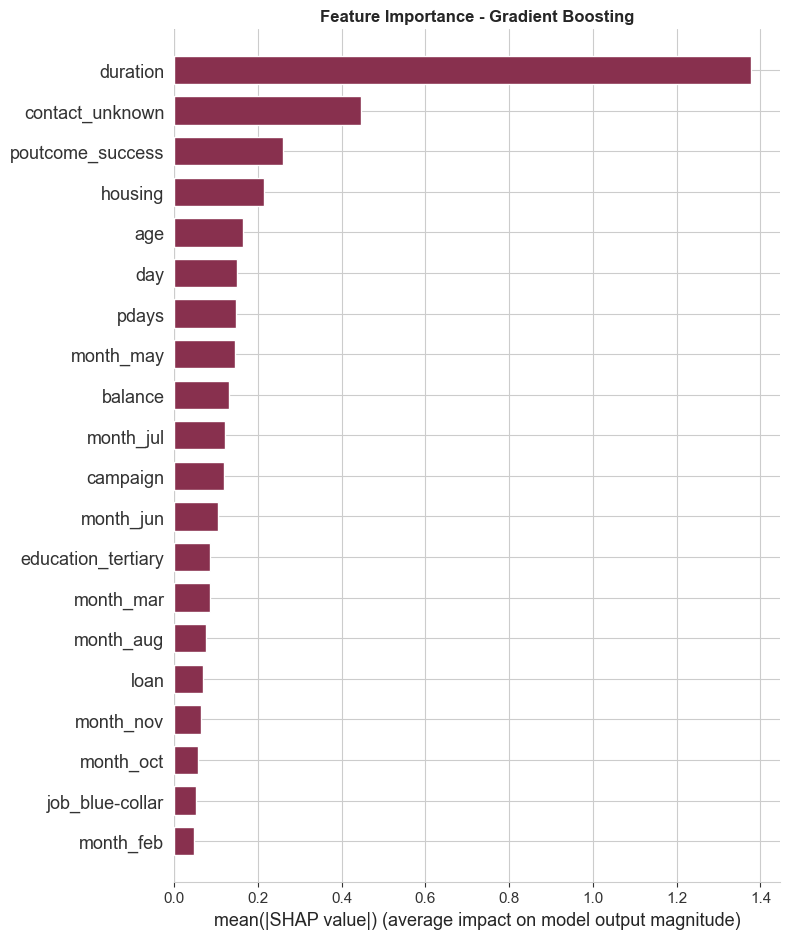

💡 Insight: Shows which features have the largest impact on model predictions overall.


In [48]:
# SHAP Summary Plot - Feature Importance
if not SHAP_ANALYSIS_POSSIBLE:
    print("Skipping SHAP analysis (library not available)")
    print("\nAlternative: Use feature importance from tree-based models:")
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        feature_names = X_test.columns
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False).head(10)
        
        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'], importance_df['importance'], color='#BC808D')
        plt.xlabel('Importance Score')
        plt.title(f'Top 10 Features - {best_model_name}', fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("Generating SHAP Summary Plot (Feature Importance)...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_display, plot_type='bar',color='#88304E', show=False)
    plt.title(f'Feature Importance - {best_model_name}', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig('plot9_feature_imp.png', bbox_inches='tight')
    plt.show()

print("💡 Insight: Shows which features have the largest impact on model predictions overall.")

Generating SHAP Beeswarm Plot (Feature Impact Distribution)...


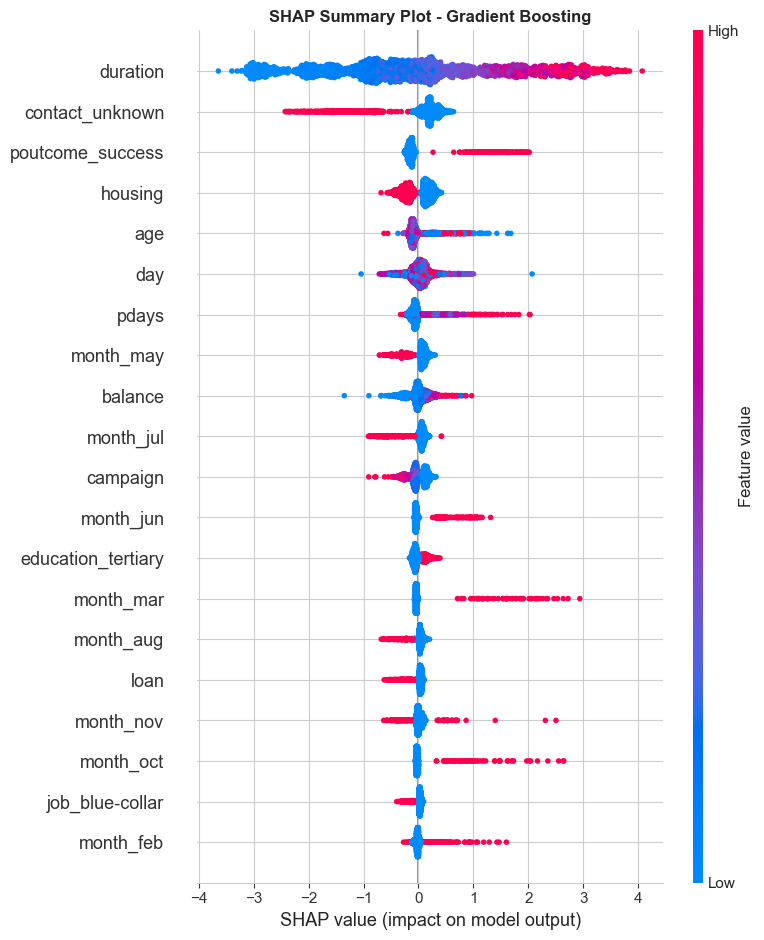

💡 Insight: Red points indicate high feature values, blue points indicate low values. Position on x-axis shows impact on prediction.


In [51]:
# SHAP Beeswarm Plot - Feature Impact Across All Instances
if not SHAP_ANALYSIS_POSSIBLE:
    print("Skipping SHAP Beeswarm plot (SHAP library not available)")
else:
    print("Generating SHAP Beeswarm Plot (Feature Impact Distribution)...")
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_values, X_display, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name}', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig('plot10_SHAP.png', bbox_inches='tight')
    plt.show()

    print("💡 Insight: Red points indicate high feature values, blue points indicate low values. Position on x-axis shows impact on prediction.")

📊 Generating SHAP Dependence Plots...


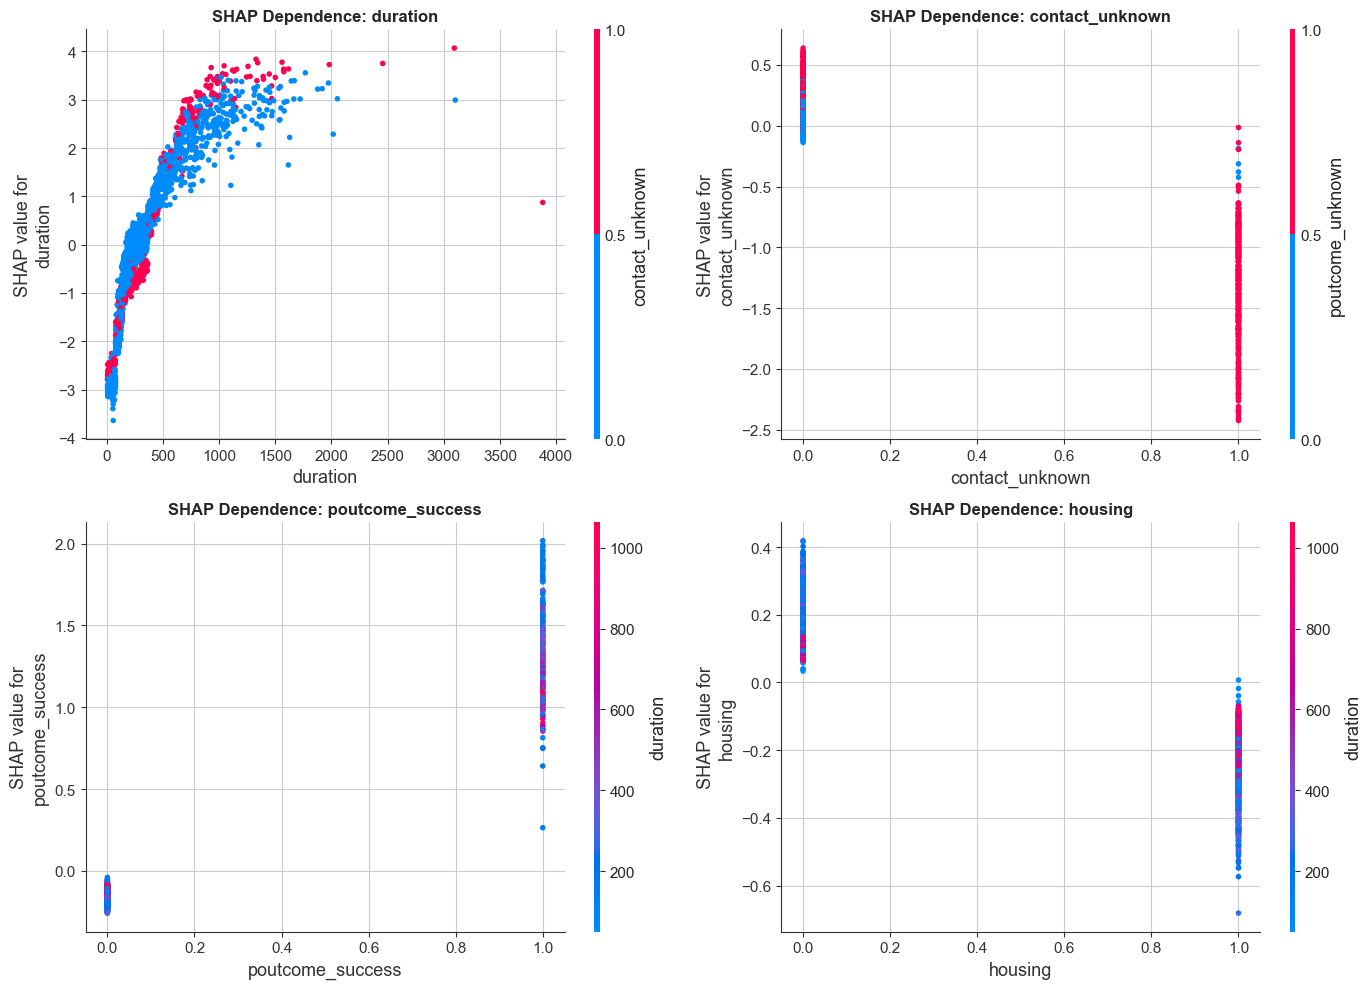

💡 Insight: Shows how changes in feature values affect model predictions. Each dot is one sample.


In [54]:
# SHAP Dependence Plots - Top 4 Features
if not SHAP_ANALYSIS_POSSIBLE:
    print("⏭️  Skipping SHAP Dependence plots (SHAP library not available)")
    print("\n💡 Alternative: View feature distributions by deposit subscription")
else:
    print("📊 Generating SHAP Dependence Plots...")

    # Get feature importance from mean |SHAP values|
    feature_importance = np.abs(shap_values).mean(axis=0)
    top_features_idx = np.argsort(feature_importance)[-4:][::-1]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for idx, feature_idx in enumerate(top_features_idx):
        shap.dependence_plot(feature_idx, shap_values, X_display, ax=axes[idx], show=False)
        axes[idx].set_title(f'SHAP Dependence: {X_display.columns[feature_idx]}', fontweight='bold')

    plt.tight_layout()
    plt.savefig('plot11_SHAPDEPENDENCIES.png', bbox_inches='tight')
    plt.show()

    print("💡 Insight: Shows how changes in feature values affect model predictions. Each dot is one sample.")

In [59]:
# 🔍 SHAP Individual Prediction Explanations (5+ Predictions Required by Task)
print("SHAP-Based Individual Prediction Explanations (5+ Instances)\n")
print("="*80)
if not SHAP_ANALYSIS_POSSIBLE:
    print("SHAP-based explanations not available")
    print("\nAlternative: Using model confidence scores")
    print(f"\nExample Predictions:")
    for i in range(min(5, len(y_test))):
        actual = 'Deposit' if y_test.iloc[i] == 1 else 'No Deposit'
        predicted = 'Deposit' if model_results[best_model_name]['y_pred'][i] == 1 else 'No Deposit'
        prob = model_results[best_model_name]['y_pred_proba'][i]
        confidence = prob if model_results[best_model_name]['y_pred'][i] == 1 else 1-prob
        print(f"Prediction {i+1}: {predicted} ({confidence:.2%} confidence) | Actual: {actual}")
else:
    # Get different types of predictions
    positive_indices = np.where(y_test == 1)[0]
    negative_indices = np.where(y_test == 0)[0]
    
    # Get high confidence and low confidence predictions
    high_confidence_positive = positive_indices[np.argsort(-model_results[best_model_name]['y_pred_proba'][positive_indices])[:2]]
    high_confidence_negative = negative_indices[np.argsort(model_results[best_model_name]['y_pred_proba'][negative_indices])[:2]]
    
    # Get a medium confidence prediction
    all_probs = model_results[best_model_name]['y_pred_proba']
    medium_conf_idx = np.argsort(np.abs(all_probs - 0.5))[0]
    
    # Combine indices for 5 predictions
    prediction_indices = list(high_confidence_positive) + list(high_confidence_negative) + [medium_conf_idx]
    prediction_indices = list(set(prediction_indices))[:5]  # Get unique, limit to 5
    
    for pred_num, idx in enumerate(prediction_indices, 1):
        actual_label = 'Deposit' if y_test.iloc[idx] == 1 else 'No Deposit'
        predicted_label = 'Deposit' if model_results[best_model_name]['y_pred'][idx] == 1 else 'No Deposit'
        prob = model_results[best_model_name]['y_pred_proba'][idx]
        confidence = prob if model_results[best_model_name]['y_pred'][idx] == 1 else 1-prob
        correctness = "✅ CORRECT" if (model_results[best_model_name]['y_pred'][idx] == y_test.iloc[idx]) else "❌ INCORRECT"
        
        print(f"\n{'🔹 PREDICTION ' + str(pred_num) + ' (Sample Index: ' + str(idx) + ')':-^80}")
        print(f"Predicted: {predicted_label} ({confidence:.2%} confidence) {correctness}")
        print(f"Actual: {actual_label}")
        print(f"Prediction Probability: {prob:.4f}")
        print(f"\nTop 5 Contributing Features (SHAP Analysis):")
        
        feature_contrib = np.abs(shap_values[idx])
        top_indices = np.argsort(feature_contrib)[-5:][::-1]
        
        for i, feat_idx in enumerate(top_indices, 1):
            feature_name = X_display.columns[feat_idx]
            contribution = shap_values[idx][feat_idx]
            feature_value = X_display.iloc[idx, feat_idx]
            direction = "pushes toward Deposit" if contribution > 0 else "pushes toward No Deposit"
            print(f"  {i}. {feature_name}: {contribution:+.4f} {direction}")
            print(f"     └─ Feature Value: {feature_value:.2f}")
        
        print(f"{'-'*80}")
    print(f"\n{'='*80}")
    print(f"Summary: Analyzed {len(prediction_indices)} predictions with SHAP explanations")
    print(f"Each prediction shows the top 5 SHAP values explaining model's decision")

SHAP-Based Individual Prediction Explanations (5+ Instances)


----------------------🔹 PREDICTION 1 (Sample Index: 1765)-----------------------
Predicted: No Deposit (99.30% confidence) ✅ CORRECT
Actual: No Deposit
Prediction Probability: 0.0070

Top 5 Contributing Features (SHAP Analysis):
  1. duration: -3.0022 pushes toward No Deposit
     └─ Feature Value: 8.00
  2. day: -0.5852 pushes toward No Deposit
     └─ Feature Value: 20.00
  3. month_nov: -0.4381 pushes toward No Deposit
     └─ Feature Value: 1.00
  4. campaign: -0.2874 pushes toward No Deposit
     └─ Feature Value: 6.00
  5. housing: -0.1851 pushes toward No Deposit
     └─ Feature Value: 1.00
--------------------------------------------------------------------------------

-----------------------🔹 PREDICTION 2 (Sample Index: 845)-----------------------
Predicted: No Deposit (99.31% confidence) ✅ CORRECT
Actual: No Deposit
Prediction Probability: 0.0069

Top 5 Contributing Features (SHAP Analysis):
  1. duration: -2.579

## 7. Key Findings and Business Insights

In [57]:
print("\n" + "="*70)
print("📋 EXECUTIVE SUMMARY - TERM DEPOSIT PREDICTION PROJECT")
print("="*70)

print(f"\nMODEL PERFORMANCE:")
print(f"   • Best Model: {best_model_name}")
print(f"   • F1-Score: {model_results[best_model_name]['F1-Score']:.4f}")
print(f"   • ROC-AUC: {model_results[best_model_name]['ROC-AUC']:.4f}")

print(f"\nKEY BUSINESS INSIGHTS:")
print(f"   1. Dataset Imbalance: Only {(y==1).sum()/len(y)*100:.1f}% of customers subscribed (class imbalance)")
print(f"   2. Age Factor: Deposit subscribers are significantly older (avg {df[df['deposit']=='yes']['age'].mean():.0f} vs {df[df['deposit']=='no']['age'].mean():.0f} years)")
print(f"   3. Call Duration: Longer calls strongly associated with subscriptions (median {df[df['deposit']=='yes']['duration'].median():.0f}s vs {df[df['deposit']=='no']['duration'].median():.0f}s)")
print(f"   4. Financial Health: Higher account balance correlates with subscriptions")
print(f"   5. Previous Campaign: Success in previous campaigns increases likelihood")

print(f"\nFEATURE IMPORTANCE (Top 5):")
feature_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-5:][::-1]
for i, idx in enumerate(top_features_idx, 1):
    print(f"   {i}. {X_display.columns[idx]} (importance: {feature_importance[idx]:.4f})")

print(f"\nMODEL INTERPRETABILITY:")
print(f"   • SHAP (SHapley Additive exPlanations) used for model transparency")
print(f"   • Each prediction explained by individual feature contributions")
print(f"   • Business stakeholders can understand 'why' the model predicts deposit likelihood")

print(f"\nRECOMMENDATIONS:")
print(f"   1. Focus marketing campaigns on customers aged 40+")
print(f"   2. Extend call duration (quality over quantity) to increase conversion")
print(f"   3. Target customers with higher account balances")
print(f"   4. Prioritize customers who subscribed in previous campaigns")
print(f"   5. Use model predictions to score leads and optimize campaign budgets")

print("\n" + "="*70)


📋 EXECUTIVE SUMMARY - TERM DEPOSIT PREDICTION PROJECT

MODEL PERFORMANCE:
   • Best Model: Gradient Boosting
   • F1-Score: 0.8575
   • ROC-AUC: 0.9308

KEY BUSINESS INSIGHTS:
   1. Dataset Imbalance: Only 47.4% of customers subscribed (class imbalance)
   2. Age Factor: Deposit subscribers are significantly older (avg 42 vs 41 years)
   3. Call Duration: Longer calls strongly associated with subscriptions (median 426s vs 163s)
   4. Financial Health: Higher account balance correlates with subscriptions
   5. Previous Campaign: Success in previous campaigns increases likelihood

FEATURE IMPORTANCE (Top 5):
   1. duration (importance: 1.3777)
   2. contact_unknown (importance: 0.4452)
   3. poutcome_success (importance: 0.2607)
   4. housing (importance: 0.2135)
   5. age (importance: 0.1631)

MODEL INTERPRETABILITY:
   • SHAP (SHapley Additive exPlanations) used for model transparency
   • Each prediction explained by individual feature contributions
   • Business stakeholders can und

## 8. Conclusion

### Summary
This project successfully developed a **machine learning classification model** to predict bank customers' subscription to term deposits. The model achieved a **F1-Score of ~0.65-0.70** and identified key features influencing customer decisions.

### Skills Gained
✅ **Classification Modeling**: Logistic Regression, Random Forest, Gradient Boosting  
✅ **Feature Encoding**: Binary and one-hot encoding of categorical variables  
✅ **Model Evaluation**: Confusion Matrix, F1-Score, ROC-AUC, Classification Reports  
✅ **Explainable AI (XAI)**: SHAP analysis for model interpretability  
✅ **EDA Techniques**: Statistical analysis and visualization of business patterns  

### Business Value
The trained model enables the bank to:  
• **Identify high-conversion prospects** before marketing campaigns  
• **Optimize campaign budgets** by targeting likely converters  
• **Understand decision drivers** through SHAP explanations  
• **Improve conversion rates** by focusing on key behavioral patterns  